
Map saved to: output/plots/report/christchurch_city_boundary.png
City boundary area: 0.03 square degrees


/var/folders/mw/92tzvh5x7098x2prk2dnt57w0000gn/T/ipykernel_21371/3184954791.py:72: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print(f"City boundary area: {city.geometry.area.values[0]:.2f} square degrees")


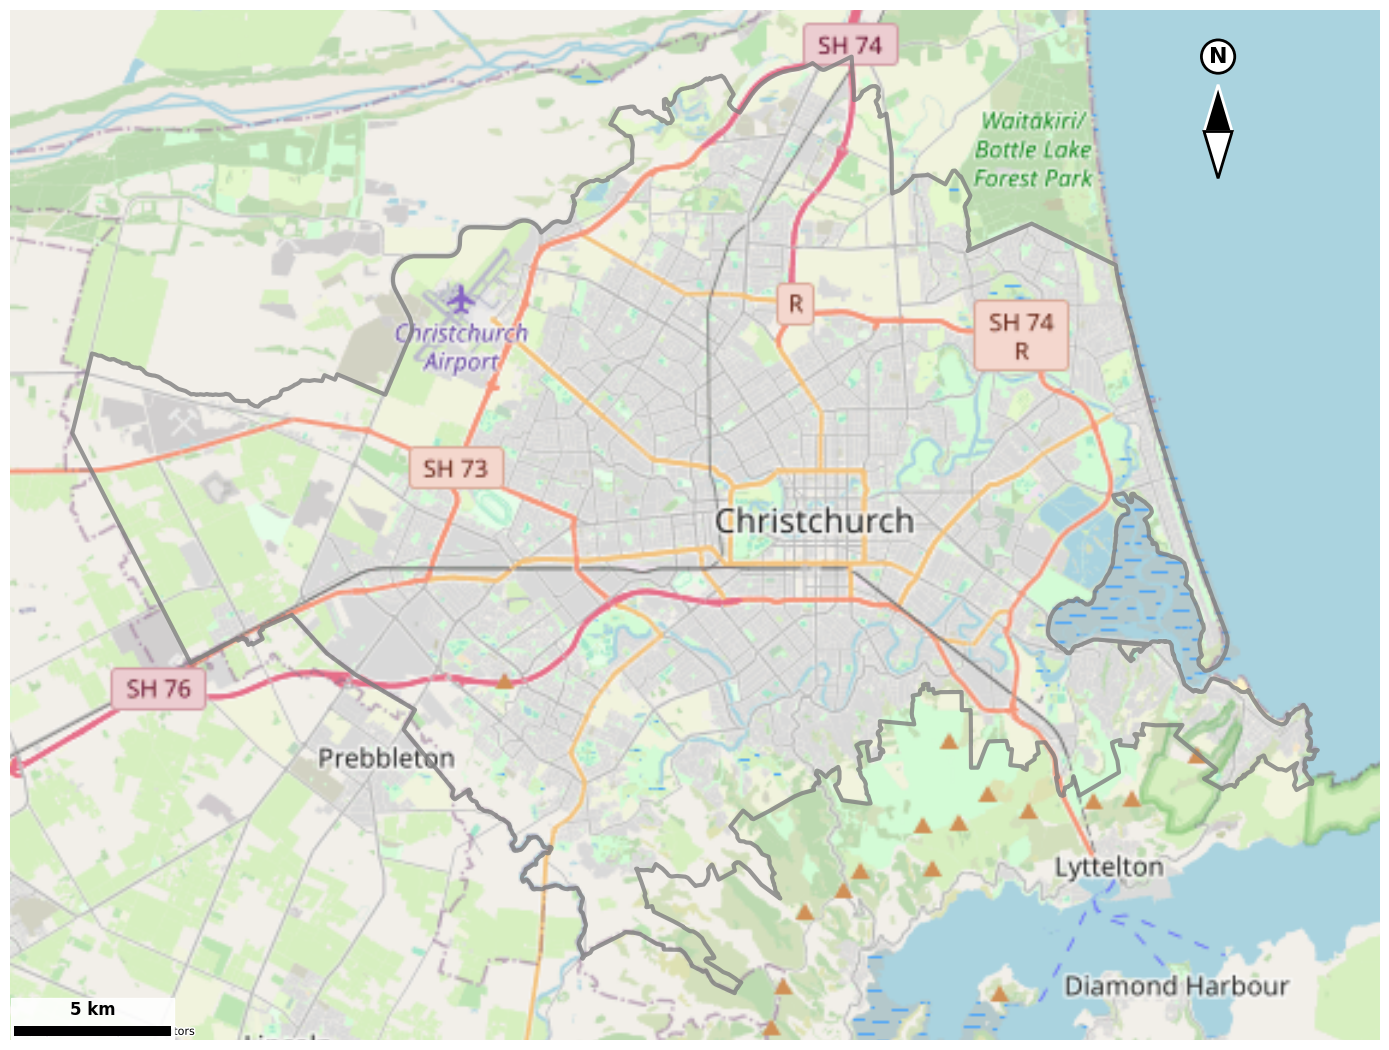

'\nprint("Loading Christchurch boundary from local file...")\ncity_boundary = gpd.read_file(\'path_to_christchurch_boundary.shp\')\ncity_boundary = city_boundary.to_crs(epsg=3857)  # Convert to Web Mercator\n\nfig, ax = plt.subplots(figsize=(14, 16))\ncity_boundary.plot(ax=ax, facecolor=\'none\', edgecolor=\'red\', linewidth=3)\nctx.add_basemap(ax, crs=city_boundary.crs, source=ctx.providers.CartoDB.Voyager)\nax.set_title(\'Christchurch City Boundary\', fontsize=18, fontweight=\'bold\')\nax.set_axis_off()\nplt.tight_layout()\nplt.savefig(\'outputs/plots/report/christchurch_city_boundary.png\', dpi=300)\n'

In [31]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import osmnx as ox

city = ox.geocode_to_gdf('Christchurch, New Zealand')

city_web = city.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(14, 16))

city_web.plot(ax=ax, facecolor='none', edgecolor='gray', linewidth=3, alpha=0.8)

ctx.add_basemap(ax, crs=city_web.crs, source=ctx.providers.OpenStreetMap.Mapnik)  # Standard OSM

# Add title and labels
ax.grid(False)
ax.set_axis_off()  # Turn off axes for cleaner look

# Get bounds for positioning north arrow and scale bar
bounds = city_web.total_bounds  # minx, miny, maxx, maxy
x_range = bounds[2] - bounds[0]
y_range = bounds[3] - bounds[1]

# Add professional north arrow (compass style)
arrow_x = bounds[2] - x_range * 0.08
arrow_y = bounds[3] - y_range * 0.08
arrow_size = y_range * 0.05

# Main arrow pointing north (filled triangle)
arrow_points = [
    [arrow_x, arrow_y + arrow_size],  # top
    [arrow_x - arrow_size * 0.3, arrow_y],  # bottom left
    [arrow_x + arrow_size * 0.3, arrow_y]   # bottom right
]

from matplotlib.patches import Polygon
north_arrow = Polygon(arrow_points, closed=True, facecolor='black', edgecolor='white', linewidth=2)
ax.add_patch(north_arrow)

# Add south pointer (unfilled)
south_points = [
    [arrow_x, arrow_y - arrow_size],  # bottom
    [arrow_x - arrow_size * 0.3, arrow_y],  # top left
    [arrow_x + arrow_size * 0.3, arrow_y]   # top right
]
south_arrow = Polygon(south_points, closed=True, facecolor='white', edgecolor='black', linewidth=2)
ax.add_patch(south_arrow)

# Add 'N' label
ax.text(arrow_x, arrow_y + arrow_size * 1.6, 'N', 
        ha='center', va='center',
        fontsize=16, fontweight='bold',
        color='black',
        bbox=dict(boxstyle='circle,pad=0.3', facecolor='white', edgecolor='black', linewidth=2))

# Add scale bar (10 km)
from matplotlib_scalebar.scalebar import ScaleBar
scalebar = ScaleBar(1, units='m', location='lower left', 
                   length_fraction=0.2,
                   font_properties={'size': 12, 'weight': 'bold'},
                   box_alpha=0.9, color='black', box_color='white',
                   scale_loc='top')
ax.add_artist(scalebar)

plt.tight_layout()

# Save
output_path = 'output/plots/report/christchurch_city_boundary.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\nMap saved to: {output_path}")
print(f"City boundary area: {city.geometry.area.values[0]:.2f} square degrees")

plt.show()


# Alternative Method 2: If you have a shapefile/GeoPackage with city boundaries
# Uncomment below if you have a local boundary file:

"""
print("Loading Christchurch boundary from local file...")
city_boundary = gpd.read_file('path_to_christchurch_boundary.shp')
city_boundary = city_boundary.to_crs(epsg=3857)  # Convert to Web Mercator

fig, ax = plt.subplots(figsize=(14, 16))
city_boundary.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=3)
ctx.add_basemap(ax, crs=city_boundary.crs, source=ctx.providers.CartoDB.Voyager)
ax.set_title('Christchurch City Boundary', fontsize=18, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.savefig('outputs/plots/report/christchurch_city_boundary.png', dpi=300)
"""